<a href="https://colab.research.google.com/github/overdosedbraincells/Healthcare_Data_Analysis/blob/main/01-Diabetes-Prediction/drtkkds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


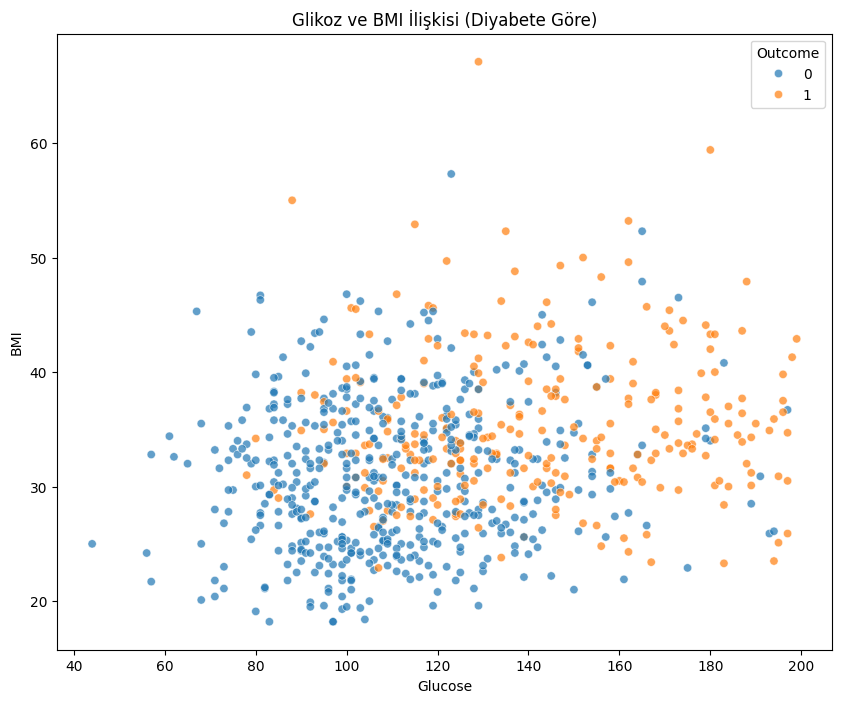

Tespit edilen aykırı hasta sayısı: len     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
3              1     89.0           66.0           23.0     94.0  28.1   
4              0    137.0           40.0           35.0    168.0  43.1   
6              3     78.0           50.0           32.0     88.0  31.0   
8              2    197.0           70.0           45.0    543.0  30.5   
13             1    189.0           60.0           23.0    846.0  30.1   
..           ...      ...            ...            ...      ...   ...   
753            0    181.0           88.0           44.0    510.0  43.3   
755            1    128.0           88.0           39.0    110.0  36.5   
760            2     88.0           58.0           26.0     16.0  28.4   
763           10    101.0           76.0           48.0    180.0  32.9   
765            5    121.0           72.0           23.0    112.0  26.2   

     DiabetesPedigree  Age  Outcome  
3               0.167   21        0

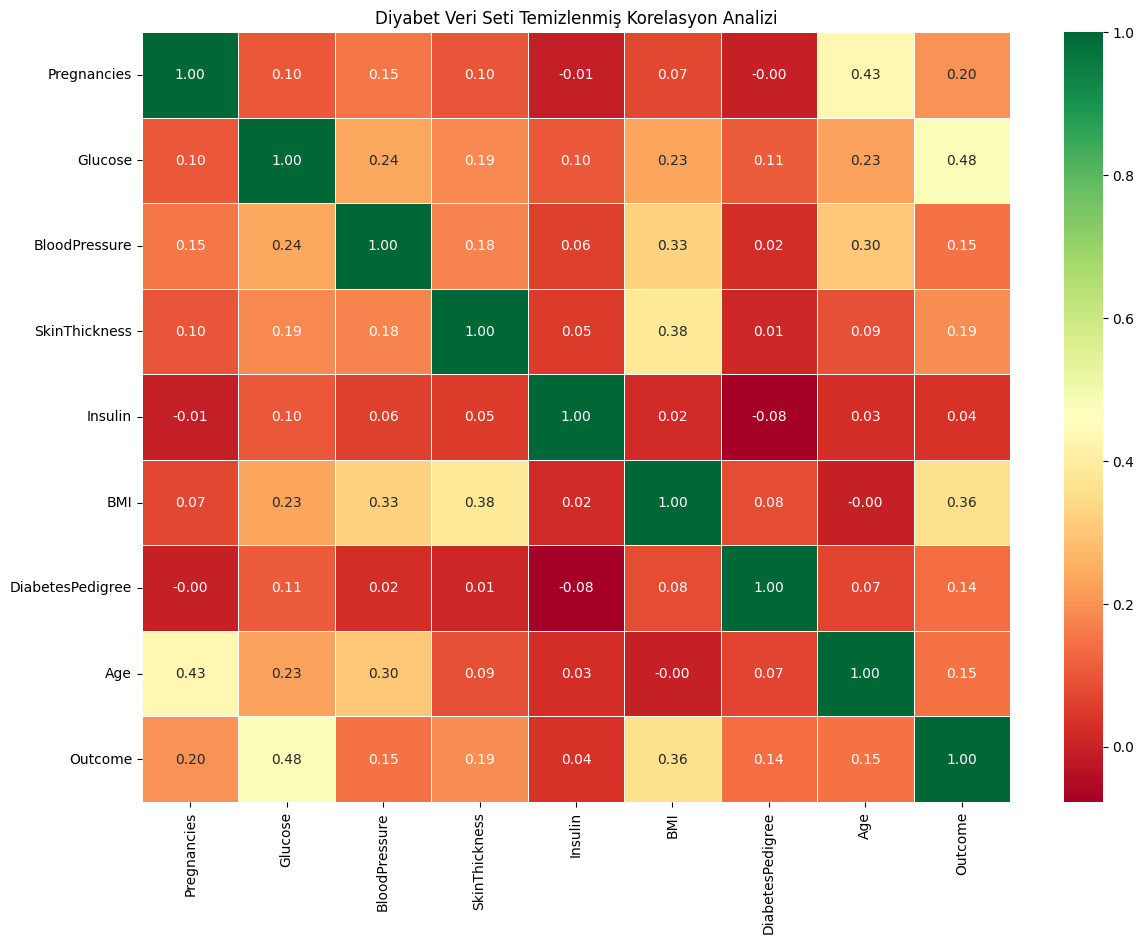

--------------------------------------------------
Eğitim seti boyutu:337
Test (Sınav) seti boyutu: 85
Modelin Başarı Skoru: %74.12

 Detaylı Klinik Performans Raporu
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        54
           1       0.70      0.52      0.59        31

    accuracy                           0.74        85
   macro avg       0.73      0.69      0.70        85
weighted avg       0.74      0.74      0.73        85



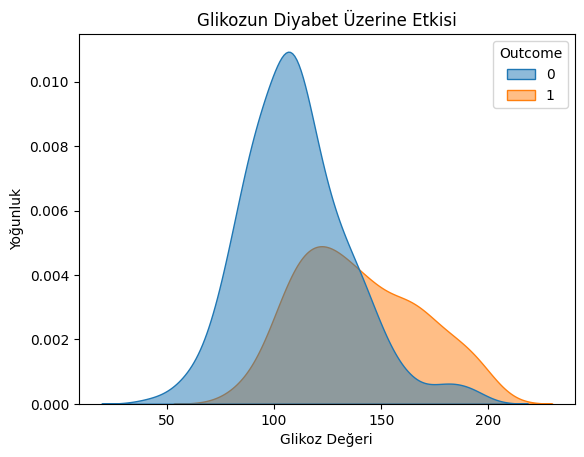

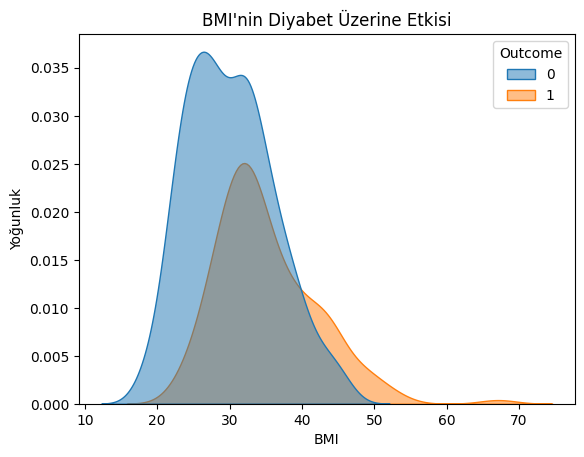

Eski başarı oranı: %74.12
Yeni başarı oranı; %74.12
--------------------------------------------------
Random Forest Başarı Skoru: %71.76
--------------------------------------------------


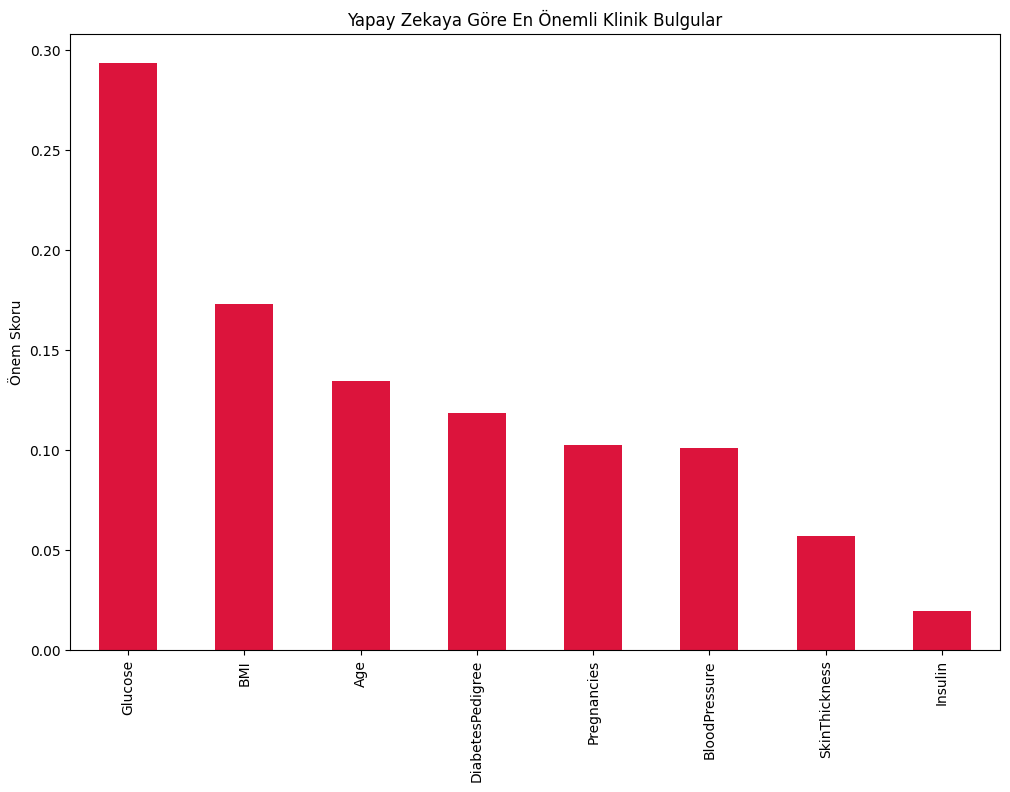

In [2]:
#Bu scriptte ilk kez IQR yöntemini kullanarak veri ayrıştırma işlemi gerçekleştirdim
#Yapay zeka modeli eğiterek klinik bulguları yorumlatmayı denedim
#Elde ettiğim sonuçta LogisticRegression ile %74, RandomForest ile %71 başarı skoru elde ettim
#Bu durumda veri setinin doğrusal modellere daha uygun olduğunu ve daha karmaşık yapay zeka modellerinin aşırı öğrenme riski taşıdığını tespit ettim


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, names=names)

#0 olması imkansız sütunları belirleyip onları NaN ile değiştirelim
columns_to_fix = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]
df[columns_to_fix] = df[columns_to_fix].replace(0, np.nan)

print(df.isnull().sum()) #Boşluk sayısını görelim

#Boş verileri medyan değerleri ile doldurma
df["Glucose"] = df["Glucose"].fillna(df["Glucose"].median())
df["BloodPressure"] = df["BloodPressure"].fillna(df["BloodPressure"].median())
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["SkinThickness"] = df["SkinThickness"].fillna(df["SkinThickness"].median())
df["Insulin"] = df["Insulin"].fillna(df["Insulin"].median())

#BMI ile glikoz arasındaki ilişkiyi diyabet durumuna (outcome) göre görelim
plt.figure(figsize=(10, 8))
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df ,alpha=0.7)
plt.title("Glikoz ve BMI İlişkisi (Diyabete Göre)")
plt.show()

#IQR yöntemi ile Insulin sütunundaki uç değerleri tespit etme
q1 = df["Insulin"].quantile(0.25)
q3 = df["Insulin"].quantile(0.75)

IQR = q3 - q1

alt_sinir = q1 - 1.5 * IQR
ust_sinir = q3 + 1.5 * IQR

aykiri_veri = df[(df["Insulin"] < alt_sinir) | (df["Insulin"] > ust_sinir)]
print(f"Tespit edilen aykırı hasta sayısı: {len(aykiri_veri)}")

#Veriyi temizleyelim
print("-" * 50)
print("Veri Sayı Dağılımı")
df_temiz = df[(df["Insulin"] >= alt_sinir) & (df["Insulin"] <= ust_sinir)]
print(f"Orijinal veri boyutu: {len(df)}")
print(f"Temizlenmiş veri boyutu: {len(df_temiz)}")
print(f"Silinen Aykırı Kayıt Sayısı: {len(df) - len(df_temiz)}")

print("-" * 50)
print("Diyabet Veri Seti Temizlenmiş Korelasyon Analizi")
plt.figure(figsize=(14, 10))

#Isı haritası için korelasyon matrisini hesaplayalım
corr_matrix = df_temiz.corr()
#Haritayı çizelim
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5)
plt.title("Diyabet Veri Seti Temizlenmiş Korelasyon Analizi")
plt.show()

#Teşhis koyabilmesi için yapay zeka eğitelim
from sklearn.model_selection import train_test_split
print("-" * 50)
#Özellikleri ve hedefi belirleme
X = df_temiz.drop("Outcome", axis=1) #Outcome dışındaki her şey
y = df_temiz["Outcome"] # Sadece diyabet sonucu (Outcom)
#Veriyi eğitim ve test için bölelim, %20 test için %80 eğitim için
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu:{len(X_train)}")
print(f"Test (Sınav) seti boyutu: {len(X_test)}")

#Diyabet teşhisi var ya da yok gibi bir durum olduğundan dolayı bir sınıflandırma problemi
#Bu yüzden tıbbi çalışmalarda en sık kullanılan ve en anlaşılır model olan Lojistik Regresyon ile başlayalım

from sklearn.linear_model import LogisticRegression
#Modeli oluşturalım
model = LogisticRegression(max_iter=1000)
#Modeli eğitelim
model.fit(X_train, y_train)

#Şimdi YZ modelinin başarısnı ölçmek için onu sınava sokalım
from sklearn.metrics import accuracy_score, classification_report
#Modele özellikleri üzerinden (yani X) hedefi üzerinde (y) tahmin yaptıralım
y_pred = model.predict(X_test)
#Başarı oranını hesaplayalım, burada hedef sonucu ile tahmin sonucunu kıyaslayarak ne kadar uyumlu olduğuna göre başarı skorunu bulalım
accuracy = accuracy_score(y_test, y_pred)
print(f"Modelin Başarı Skoru: %{accuracy*100:.2f}")
#Detaylı bir rapor alalım
print("\n Detaylı Klinik Performans Raporu")
print(classification_report(y_test, y_pred))

#Glikozun diyabet üzerine etkisini gösterelim
sns.kdeplot(x="Glucose", hue="Outcome", data=df_temiz, fill=True, alpha=0.5)
plt.title("Glikozun Diyabet Üzerine Etkisi")
plt.xlabel("Glikoz Değeri")
plt.ylabel("Yoğunluk")
plt.show()

#Aynısını BMI için yapalım
sns.kdeplot(x="BMI", hue="Outcome", data=df_temiz, fill=True, alpha=0.5)
plt.title("BMI'nin Diyabet Üzerine Etkisi")
plt.xlabel("BMI")
plt.ylabel("Yoğunluk")
plt.show()

#şimdi başarı oranını artırmak için StandardScaler kullanalım
from sklearn.preprocessing import StandardScaler

#Ölçeklendiriciyi tanımlayalım
scaler = StandardScaler()
#Sadece özellikleri (yani X) ölçeklendirelim
X_scaled = scaler.fit_transform(X)
#Şimdi ölçeklendirilmiş veri ile veriyi tekrardan bölelim
X_train ,X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
#Modeli tekrardan eğitelim
model_scaled = LogisticRegression()
model_scaled.fit(X_train, y_train)
#Yeni başarıyı ölçelim
y_pred_new = model_scaled.predict(X_test)
new_accuracy = accuracy_score(y_test, y_pred_new)

print(f"Eski başarı oranı: %{accuracy*100:.2f}")
print(f"Yeni başarı oranı; %{new_accuracy*100:.2f}")

#Eski başarı oranı ile yeni başarı oranının aynı olması LogisticRegression yönteminin sınırına ulaştığımız anlamına geliyor
#Skoru artırmak için RandomForest kullanalım

from sklearn.ensemble import RandomForestClassifier

#Modeli tanımlayalım ---> 100 ağaçtan oluşan bir orman oluşturalım, her ağaç konsültasyon yapabileceğimiz bir doktor meslektaşımız gibi düşünün
orman_modeli = RandomForestClassifier(n_estimators=100, random_state=42)
#modeli eğitelim --> orijinal X_train veya ölçeklendirilmiş olanı fark etmez, ben X_train ile deneyeceğim
orman_modeli.fit(X_train, y_train)
#Tahmin yaptıralım
y_pred_orman = orman_modeli.predict(X_test)
orman_skoru = accuracy_score(y_test, y_pred_orman)

print("-" * 50)
print(f"Random Forest Başarı Skoru: %{orman_skoru*100:.2f}")

#Şu an yaşadığımız duruma veri biliminde "Complexity Paradox" deniyor
#Daha karmaşık model = daha iyi sonuç olmuyor
#Şimdi Random Forest'ın bir yeteneği olan "Feature Importance"ı kullanarak
#hangi tıbbi değerin diyabet teşhisinde ne kadar söz sahibi olduğunu görelim

print("-" * 50)

#Modelin hangi özelliklere ne kadar önem verdiğine bakalım
onem_dereceleri = pd.Series(orman_modeli.feature_importances_, index=X.columns)
onem_dereceleri = onem_dereceleri.sort_values(ascending=False)

#Görselleştirelim
plt.figure(figsize=(12, 8))
onem_dereceleri.plot(kind="bar", color="crimson")
plt.ylabel("Önem Skoru")
plt.title("Yapay Zekaya Göre En Önemli Klinik Bulgular")
plt.show()
